In [35]:
import pandas as pd
import numpy as np
import matplotlib as plt


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [3]:
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [4]:
df = pd.read_csv("C:/Users/tcaal/Desktop/Data Science Project Stuff/College Placement/College.csv")

In [5]:
print(df.head())

   sl_no gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s  degree_p  \
0      1      M  67.00   Others  91.00   Others  Commerce     58.00   
1      2      M  79.33  Central  78.33   Others   Science     77.48   
2      3      M  65.00  Central  68.00  Central      Arts     64.00   
3      4      M  56.00  Central  52.00  Central   Science     52.00   
4      5      M  85.80  Central  73.60  Central  Commerce     73.30   

    degree_t workex  etest_p specialisation  mba_p      status    salary  
0   Sci&Tech     No     55.0         Mkt&HR  58.80      Placed  270000.0  
1   Sci&Tech    Yes     86.5        Mkt&Fin  66.28      Placed  200000.0  
2  Comm&Mgmt     No     75.0        Mkt&Fin  57.80      Placed  250000.0  
3   Sci&Tech     No     66.0         Mkt&HR  59.43  Not Placed       NaN  
4  Comm&Mgmt     No     96.8        Mkt&Fin  55.50      Placed  425000.0  


In [6]:
# Salary variable was removed, salary is directly related to being accepted and doesn't serve as a predictor

df = df.drop(columns = ['salary'])

In [7]:
print(df.head())

   sl_no gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s  degree_p  \
0      1      M  67.00   Others  91.00   Others  Commerce     58.00   
1      2      M  79.33  Central  78.33   Others   Science     77.48   
2      3      M  65.00  Central  68.00  Central      Arts     64.00   
3      4      M  56.00  Central  52.00  Central   Science     52.00   
4      5      M  85.80  Central  73.60  Central  Commerce     73.30   

    degree_t workex  etest_p specialisation  mba_p      status  
0   Sci&Tech     No     55.0         Mkt&HR  58.80      Placed  
1   Sci&Tech    Yes     86.5        Mkt&Fin  66.28      Placed  
2  Comm&Mgmt     No     75.0        Mkt&Fin  57.80      Placed  
3   Sci&Tech     No     66.0         Mkt&HR  59.43  Not Placed  
4  Comm&Mgmt     No     96.8        Mkt&Fin  55.50      Placed  


In [8]:
# Converting acceptance to binary outcome of 1 (Placed) or 0 (Not Placed)

df['status'] = df['status'].map({'Placed':1,'Not Placed':0})

In [13]:
# Since the random forest classifier function cannot process strings, all other variables are converted too

df['gender'] = df['gender'].map({'M':1,'F':0})
df['ssc_b'] = df['ssc_b'].map({'Others':1,'Central':0})
df['hsc_b'] = df['hsc_b'].map({'Others':1,'Central':0})
df['hsc_s'] = df['hsc_s'].map({'Arts':2,'Science':1,'Commerce':0})
df['degree_t'] = df['degree_t'].map({'Comm&Mgmt':2,'Sci&Tech':0,'Others':1})
df['workex'] = df['workex'].map({'Yes':1,'No':0})
df['specialisation'] = df['specialisation'].map({'Mkt&Fin':1,'Mkt&HR':0})

In [14]:
# Splitting the data based on the target variable (status) and all other features

x = df.drop(columns = ['status'])
y = df['status']

In [15]:
# Split data based on training data to train the model and test to assess performance

# test_size dictates an 80/20 split, random_state 42 sets a seed for for reproducibility

X_train, X_test, y_train, y_test = train_test_split(x, y, 
                                                    test_size = 0.2, 
                                                    random_state = 42, 
                                                    stratify = y)

In [16]:
# Assigns object to random forest model and fits the training data

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
# Now that the model has been fitted, the test data set can be utilized

y_pred = rf.predict(X_test)

In [18]:
# The outcome of status from the above prediction is compared to the true test values to assess accuracy

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8372093023255814


In [30]:
# While the model resulted in an accuracy of approximately 84%, hyperparameter tuning can improve this

param = {
  'n_estimators': randint(100, 500), # Number of decision trees
  'max_depth': randint(3, 15), # Depth of decision trees, can result in overfitting or underfitting though
  'min_samples_split': randint(2, 10),
  'min_samples_leaf': randint(1, 5)
}


# New a random forest classifier

rf = RandomForestClassifier(random_state = 42, 
                            n_jobs = -1)

# Use random search to find the best hyperparameters

rand_search = RandomizedSearchCV(
  rf, param_distributions = param,
  n_iter = 10, cv = 5, scoring = 'accuracy',
  n_jobs = -1, random_state = 42)


In [ ]:
# Now that the random search has been created, it can be fitted to the training set

rand_search.fit(X_train, y_train)
print(rand_search.best_estimator_)

RandomForestClassifier(max_depth=13, min_samples_leaf=3, min_samples_split=9,
                       n_estimators=472, n_jobs=-1, random_state=42)


In [33]:
# Creating a variable for the best model

best_rf = rand_search.best_estimator_

# Print the best hyperparameters

print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 13, 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 472}


In [ ]:
# From 472 decision treees, the optimal parameters had a max depth of 13, a minimum sample leaf of 3 and a minimum sample split of 9

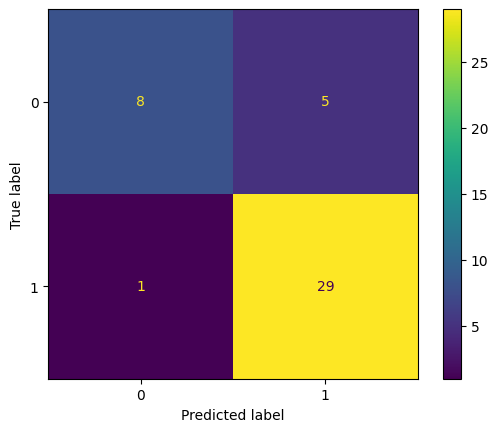

In [ ]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Creates a confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix = cm).plot();

# False positives (Type I) are shown in the top right while - rejecting a true null hypothesis
# False negatives (Type II) shown in the bottom left - fail to reject a false null hypothesis

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision) # Accuracy of positive predictions
print("Recall:", recall) # Completeness of finding all positives

Accuracy: 0.8604651162790697
Precision: 0.8529411764705882
Recall: 0.9666666666666667


In [ ]:
# Here, the accuracy increased by approximately 2%; a precision of 85% and a recall of 97% can be observed

<Axes: >

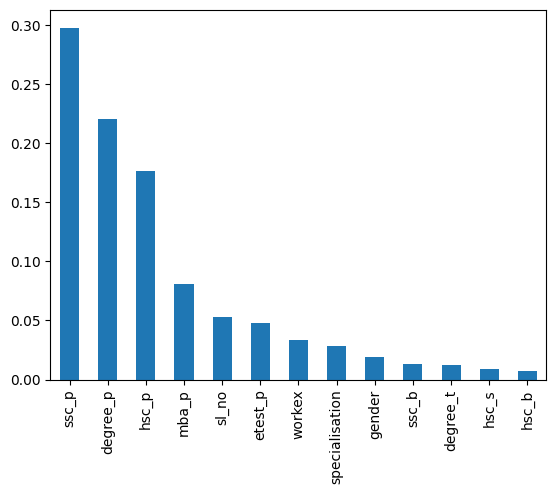

In [41]:
# Create a series containing feature importances from the model and feature names from the training data
importances = pd.Series(best_rf.feature_importances_, index = X_train.columns)
importances.sort_values(ascending = False).plot.bar()
